<a href="https://colab.research.google.com/github/VardhanVelamakanni/EEG_GAF/blob/main/EEG_GAF_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_dir = "/content/drive/MyDrive/gaf_dataset"

In [ ]:
import os

print("Classes:", os.listdir(base_dir))
print("Normal:", len(os.listdir(base_dir + "/normal")))
print("Seizure:", len(os.listdir(base_dir + "/seizure")))

Classes: ['normal', 'seizure']
Normal: 2657
Seizure: 386


In [ ]:
!pip install tensorflow scikit-learn

In [ ]:
import tensorflow as tf

img_size = (224, 224)
batch_size = 16

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 3043 files belonging to 2 classes.
Using 2435 files for training.
Found 3043 files belonging to 2 classes.
Using 608 files for validation.


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
normal_count = len(os.listdir(base_dir + "/normal"))
seizure_count = len(os.listdir(base_dir + "/seizure"))

total = normal_count + seizure_count

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * seizure_count)
}

print("Class Weights:", class_weight)

Class Weights: {0: 0.5726383138878435, 1: 3.9417098445595853}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
import tensorflow as tf

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)   # smaller = faster
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight
)

Epoch 1/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 122s 787ms/step - accuracy: 0.8456 - loss: 0.3559 - val_accuracy: 0.7878 - val_loss: 0.4457
Epoch 2/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 116s 758ms/step - accuracy: 0.8534 - loss: 0.3243 - val_accuracy: 0.7993 - val_loss: 0.4279
Epoch 3/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 143s 766ms/step - accuracy: 0.8595 - loss: 0.3130 - val_accuracy: 0.8076 - val_loss: 0.4134
Epoch 4/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 113s 737ms/step - accuracy: 0.8715 - loss: 0.2998 - val_accuracy: 0.8059 - val_loss: 0.4062
Epoch 5/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 164s 879ms/step - accuracy: 0.8789 - loss: 0.2890 - val_accuracy: 0.8092 - val_loss: 0.3994
Epoch 6/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 118s 770ms/step - accuracy: 0.8817 - loss: 0.2855 - val_accuracy: 0.8158 - val_loss: 0.3895
Epoch 7/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 121s 788ms/step - accuracy: 0.8879 - loss: 0.2656 - val_accuracy: 0.8174 - val_loss: 0.3983
Epoch 8/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 120s 785ms/step - accuracy: 0.8932 -

In [ ]:
# Unfreeze top layers only
base_model.trainable = True

for layer in base_model.layers[:-30]:   # keep most frozen
    layer.trainable = False

# Recompile with LOW LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight
)

Epoch 1/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8435 - loss: 0.3380 - val_accuracy: 0.4227 - val_loss: 2.1704
Epoch 2/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 141s 919ms/step - accuracy: 0.8653 - loss: 0.2739 - val_accuracy: 0.4951 - val_loss: 1.5699
Epoch 3/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 142s 926ms/step - accuracy: 0.8723 - loss: 0.2684 - val_accuracy: 0.5181 - val_loss: 1.4393
Epoch 4/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 140s 910ms/step - accuracy: 0.8854 - loss: 0.2187 - val_accuracy: 0.5740 - val_loss: 1.2407
Epoch 5/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 146s 941ms/step - accuracy: 0.9031 - loss: 0.2129 - val_accuracy: 0.6316 - val_loss: 0.9773
Epoch 6/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9060 - loss: 0.1920 - val_accuracy: 0.6711 - val_loss: 0.8446
Epoch 7/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 142s 922ms/step - accuracy: 0.9039 - loss: 0.1848 - val_accuracy: 0.7039 - val_loss: 0.7433
Epoch 8/25
153/153 ━━━━━━━━━━━━━━━━━━━━ 142s 928ms/step - accuracy: 0.9265 - loss:

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    base_dir,
    validation_split=0.1,   # new split
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=16
)

Found 3043 files belonging to 2 classes.
Using 304 files for validation.


In [ ]:
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

In [ ]:
loss, acc = model.evaluate(test_ds)

print(" Test Accuracy:", acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 609ms/step - accuracy: 0.9539 - loss: 0.1238
 Test Accuracy: 0.9539473652839661


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(classification_report(y_true, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 985ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       275
           1       0.69      0.93      0.79        29

    accuracy                           0.95       304
   macro avg       0.84      0.94      0.88    

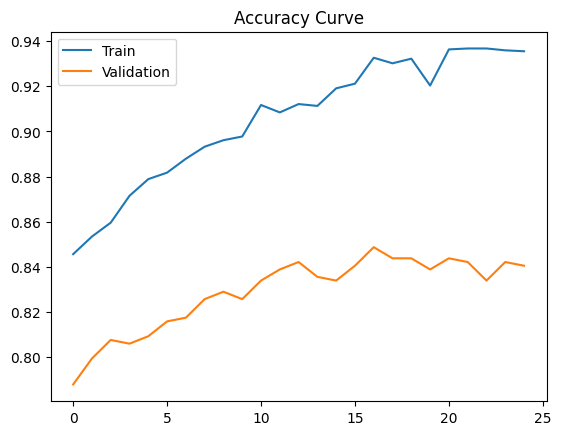

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Curve")
plt.show()